In [29]:
# !pip install pandas
import pandas as pd

In [30]:
dataFrame = pd.read_csv("./data/spam.csv", encoding='latin-1')

In [31]:
unnamed_mask = dataFrame["Unnamed: 2"].notna()
df2 = dataFrame[unnamed_mask]
df2

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [32]:
# isNaN = dataFrame.isnull()

# print(isNaN)
# print("null count", isNaN.sum())

unnamed_mask = dataFrame["Unnamed: 2"].notna()
df2 = dataFrame[unnamed_mask]
df2

target_cols =  ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
mask = dataFrame[target_cols].notna().any(axis=1)

valid_data = dataFrame[mask]
valid_data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [33]:
dataFrame.rename(columns={"v1": "label", "v2": "text"}, inplace=True)
print(dataFrame)
print(dataFrame["text"].isnull().sum()) # 0

     label                                               text Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [34]:
dataFrame["text"] = dataFrame["text"].fillna("") + " " + dataFrame["Unnamed: 2"].fillna("") + " " + dataFrame["Unnamed: 3"].fillna("") + " " + dataFrame["Unnamed: 4"].fillna("")

# print(dataFrame["text"].isnull().sum())

# 여러 개의 공백들을 하나로 변경하고 앞 뒤의 공백을 제거 \s는 여러 공백을 확인하는 정규표현식
dataFrame["text"].str.replace("\s", " ", regex=True).str.strip()
# dataFrame.head()
dataFrame.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1, inplace=True)
dataFrame.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [35]:
print(dataFrame["text"].value_counts().sum())

5572


In [36]:
dataFrame.describe()


,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [37]:
print(dataFrame["text"].duplicated().sum())
# duplicates = dataFrame[dataFrame["text"].duplicated(keep="first")]
# print(duplicates["text"].head(10))

403


In [38]:
# 원본에서 중복 제거 (첫 번째 것만 남기고 나머지 삭제)
dataFrame.drop_duplicates(subset=["text"], keep="first", inplace=True)
dataFrame["text"].describe()

# 제거 후 인덱스 재정렬
dataFrame.reset_index(drop=True, inplace=True)

print("현재 남은 중복 개수:", dataFrame["text"].duplicated().sum())

현재 남은 중복 개수: 0


In [39]:
# # print(dataFrame.value_counts().sum())
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(dataFrame["text"])


In [40]:
import re

text = dataFrame["text"]
print(text)

def clean_special_chars(text):  
    text = re.sub("[^a-zA-Z0-9\s]", "", text)

    text = re.sub("\s+", " ", text).strip()
    return text

dataFrame["text_clean"] = dataFrame["text"].apply(clean_special_chars)
# print(dataFrame[["text", "text_clean"]].head())


0       Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...   
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5164    This is the 2nd time we have tried 2 contact u...
5165             Will Ì_ b going to esplanade fr home?   
5166    Pity, * was in mood for that. So...any other s...
5167    The guy did some bitching but I acted like i'd...
5168                        Rofl. Its true to its name   
Name: text, Length: 5169, dtype: object


In [41]:
!pip install nltk
import nltk
from nltk.corpus import stopwords

# 1. NLTK 불용어 데이터셋 다운로드 (최초 1회)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /Users/choi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
def remove_stopwords_new(text):
    text = text.lower()
    words = text.split()

    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

In [43]:
dataFrame["text_final"] = dataFrame["text_clean"].apply(remove_stopwords_new)
display(dataFrame[['text_clean', 'text_final']].head(40))

,text_clean,text_final
0,Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...
1,Ok lar Joking wif u oni,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor U c already then say,u dun say early hor u c already say
4,Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though
5,FreeMsg Hey there darling its been 3 weeks now...,freemsg hey darling 3 weeks word back id like ...
6,Even my brother is not like to speak with me T...,even brother like speak treat like aids patent
7,As per your request Melle Melle Oru Minnaminun...,per request melle melle oru minnaminunginte nu...
8,WINNER As a valued network customer you have b...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more U R entitled...,mobile 11 months u r entitled update latest co...


In [44]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_words(text):
    words = text.split()
    
    stemmed_words = [stemmer.stem(w) for w in words]
    return " ".join(stemmed_words)

In [45]:
dataFrame["text_stemmed"] = dataFrame["text_final"].apply(stem_words)
display(dataFrame[["text_final", "text_stemmed"]].head())

,text_final,text_stemmed
0,go jurong point crazy available bugis n great ...,go jurong point crazi avail bugi n great world...
1,ok lar joking wif u oni,ok lar joke wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say early hor u c already say,u dun say earli hor u c alreadi say
4,nah dont think goes usf lives around though,nah dont think goe usf live around though


In [46]:
# TF-IDF 벡터화 코드 진행

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=3000) # 가장 빈도수가 높은 단어를 3천개만 선택해 차원 축소

# 레이블 인코딩
dataFrame["label"] = dataFrame["label"].map({"ham": 0, "spam": 1})
display(dataFrame["label"].head())

X = tfidf.fit_transform(dataFrame["text_stemmed"]).toarray()
y = dataFrame["label"].values


0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [47]:
print(dataFrame["label"].value_counts())

label
0    4516
1     653
Name: count, dtype: int64


In [48]:
print(f"숫자로 변환된 행렬의 크기: {X.shape}")

숫자로 변환된 행렬의 크기: (5169, 3000)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습용 데이터, {len(X_train)}")
print(f"테스트용 데이터, {len(X_test)}")

학습용 데이터, 4135
테스트용 데이터, 1034


In [50]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"정확도: {accuracy * 100:.2f}%")
print("--------------------------------------------")
print("상세 리포트")
print(classification_report(y_test, y_pred))

정확도: 97.58%
--------------------------------------------
상세 리포트
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.83      0.91       145

    accuracy                           0.98      1034
   macro avg       0.99      0.91      0.95      1034
weighted avg       0.98      0.98      0.97      1034



In [53]:
# 테스트 메세지로 스팸 판별 테스트

def predict_spam():
    new_message = input("send text")
    clean_text = clean_special_chars(new_message)
    no_stopwords = remove_stopwords_new(clean_text)
    stemmed_text = stem_words(no_stopwords)

    vectorized_text = tfidf.transform([stemmed_text]).toarray()

    prediction = nb_model.predict(vectorized_text)[0]

    probability = nb_model.predict_proba(vectorized_text)[0]
    
    if prediction == 1:
        return f"스팸 메세지 (확률: {probability[1]*100:.2f}%)"
    else:
        return f"정상 메세지 (확률: {probability[0]*100:.2f}%)"

predict_spam()

'정상 메세지 (확률: 85.09%)'

In [56]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt



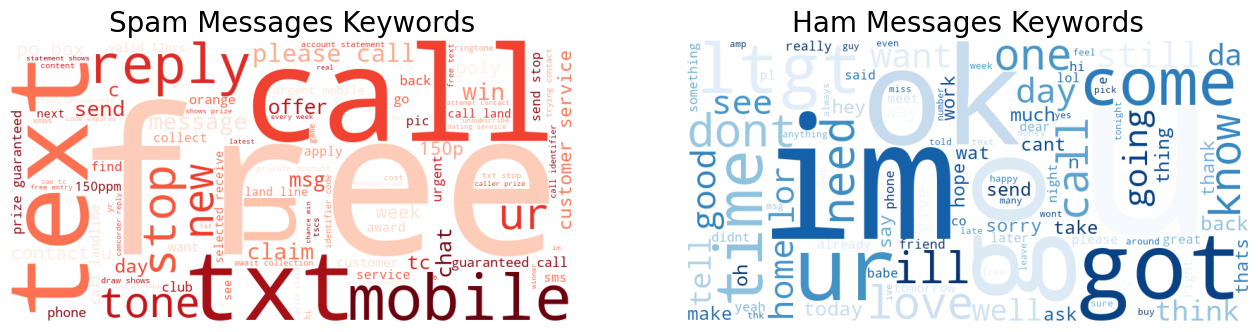

In [58]:
# 시각화 설정 (나란히 두 개를 그립니다)
plt.figure(figsize=(16, 8))

# 1. 스팸(Spam) 메세지 워드 클라우드
spam_words = " ".join(dataFrame[dataFrame["label"] == 1]["text_final"])
spam_cloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds", max_words=100).generate(spam_words)

plt.subplot(1, 2, 1)
plt.imshow(spam_cloud.to_image())
plt.title("Spam Messages Keywords", fontsize=20)
plt.axis("off")

# 2. 정상(Ham) 메세지 워드 클라우드
ham_words = " ".join(dataFrame[dataFrame["label"] == 0]["text_final"])
ham_cloud = WordCloud(width=800, height=400, background_color="white", colormap="Blues", max_words=100).generate(ham_words)

plt.subplot(1, 2, 2)
plt.imshow(ham_cloud.to_image())
plt.title("Ham Messages Keywords", fontsize=20)
plt.axis("off")

plt.show()

In [ ]:
# LSTM 모델 데이터 전처리
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [61]:
vocab_size = 5000
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(dataFrame["text_final"])

word_index = tokenizer.word_index
print(f"고유 단어 개수: {len(word_index)}")

sequences = tokenizer.texts_to_sequences(dataFrame["text_final"])
print(sequences)

고유 단어 개수: 9444
[[9, 3736, 622, 559, 593, 1025, 43, 56, 361, 1026, 76, 2453, 1027, 16, 3737, 66], [12, 194, 1179, 318, 2, 1554], [13, 411, 5, 851, 852, 131, 2454, 1180, 560, 2455, 2456, 173, 2457, 24, 2454, 2458, 247, 411, 3738, 34, 3739, 329, 3740], [2, 132, 75, 235, 2459, 2, 88, 67, 75], [780, 8, 38, 330, 724, 1555, 112, 331], [668, 51, 1336, 108, 474, 274, 33, 256, 15, 275, 32, 1556, 12, 236, 1181, 3741, 25, 276, 2460], [126, 493, 15, 277, 524, 15, 3742, 3743], [146, 1337, 2461, 2461, 2462, 3744, 3745, 3746, 494, 1557, 2463, 1182, 412, 1183, 166, 1557], [623, 853, 332, 156, 362, 3747, 934, 77, 854, 62, 3, 3748, 62, 304, 3749, 413, 669, 475], [49, 935, 670, 2, 36, 1184, 451, 248, 495, 855, 333, 13, 3, 49, 451, 1558, 13, 3750], [4, 121, 30, 129, 8, 21, 171, 174, 936, 114, 98, 83, 3751, 319, 39], [1878, 3752, 131, 109, 249, 3753, 525, 34, 3754, 25, 2464, 293, 3755, 3756, 192, 3757, 329, 40, 1879, 10, 856], [115, 92, 58, 13, 2465, 3758, 77, 3759, 34, 274, 62, 3760, 452, 3761, 3762, 725, 

In [69]:
max_length = 50
padding_type = "post"
truncating_type = "post"

X_final = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=truncating_type)
print(f"첫번째 데이터 변환 결과: \n{X_final[0]}")
print(f"데이터 형태: {X_final.shape}")

첫번째 데이터 변환 결과: 
[   9 3736  622  559  593 1025   43   56  361 1026   76 2453 1027   16
 3737   66    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
데이터 형태: (5169, 50)


In [ ]:
# LSTM 모델 설계 코드
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = 

2       Free entry in 2 a wkly comp to win FA Cup fina...
3             U dun say so early hor U c already then say
4       Nah I dont think he goes to usf he lives aroun...
5       FreeMsg Hey there darling its been 3 weeks now...
6       Even my brother is not like to speak with me T...
                              ...                        
5164    This is the 2nd time we have tried 2 contact u...
5165                    Will b going to esplanade fr home
5166    Pity was in mood for that Soany other suggestions
5167    The guy did some bitching but I acted like id ...
5168                            Rofl Its true to its name
Name: text_clean, Length: 5167, dtype: object